<a href="https://colab.research.google.com/github/sakthi13854/AI-ML-Training/blob/main/AI_Ml_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# 1.Understandings of Data

In [ ]:
data = { "Order_ID": ["ORD001","ORD002","ORD003","ORD004","ORD005","ORD006","ORD007","ORD008","ORD009","ORD010", "ORD011","ORD012","ORD013","ORD014","ORD015","ORD016","ORD017","ORD018","ORD019","ORD020"],
        "Product_Category": ["Electronics","Clothing","Groceries","Electronics","Furniture", "Clothing","Electronics","Groceries","Furniture","Clothing", "Electronics","Furniture","Groceries","Clothing","Electronics", "Furniture","Groceries","Electronics","Clothing","Furniture"],
         "Customer_Age": [25,32,28,41,35,24,29,45,38,27,31,42,26,36,30,48,33,29,40,37],
         "Quantity": [2,4,6,1,3,5,2,8,2,4,3,1,7,5,2,2,9,3,4,2],
         "Unit_Price": [500,800,120,1500,2200,650,1800,100,2500,750,1200,3000,150,900,2000,2800,130,1600,850,2400],
         "Discount": [5,10,0,15,8,5,10,0,12,5,8,15,0,10,5,12,10,0,8,5],
         "Delivery_Days": [3,5,2,4,7,3,4,2,8,5,3,6,2,4,3,7,2,4,5,6],
         "Sales": [950,2880,720,1275,6072,3087,3240,800,4400,2850, 3312,2550,1050,4050,3520,5040,1170,4416,3230,4560]
         }
df = pd.DataFrame(data)
df

,Order_ID,Product_Category,Customer_Age,Quantity,Unit_Price,Discount,Delivery_Days,Sales
0,ORD001,Electronics,25,2,500,5,3,950
1,ORD002,Clothing,32,4,800,10,5,2880
2,ORD003,Groceries,28,6,120,0,2,720
3,ORD004,Electronics,41,1,1500,15,4,1275
4,ORD005,Furniture,35,3,2200,8,7,6072
5,ORD006,Clothing,24,5,650,5,3,3087
6,ORD007,Electronics,29,2,1800,10,4,3240
7,ORD008,Groceries,45,8,100,0,2,800
8,ORD009,Furniture,38,2,2500,12,8,4400
9,ORD010,Clothing,27,4,750,5,5,2850


In [ ]:
df.head()

,Order_ID,Product_Category,Customer_Age,Quantity,Unit_Price,Discount,Delivery_Days,Sales
0,ORD001,Electronics,25,2,500,5,3,950
1,ORD002,Clothing,32,4,800,10,5,2880
2,ORD003,Groceries,28,6,120,0,2,720
3,ORD004,Electronics,41,1,1500,15,4,1275
4,ORD005,Furniture,35,3,2200,8,7,6072


In [ ]:
df.tail()

,Order_ID,Product_Category,Customer_Age,Quantity,Unit_Price,Discount,Delivery_Days,Sales
15,ORD016,Furniture,48,2,2800,12,7,5040
16,ORD017,Groceries,33,9,130,10,2,1170
17,ORD018,Electronics,29,3,1600,0,4,4416
18,ORD019,Clothing,40,4,850,8,5,3230
19,ORD020,Furniture,37,2,2400,5,6,4560


In [ ]:
df.shape

(20, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order_ID          20 non-null     object
 1   Product_Category  20 non-null     object
 2   Customer_Age      20 non-null     int64 
 3   Quantity          20 non-null     int64 
 4   Unit_Price        20 non-null     int64 
 5   Discount          20 non-null     int64 
 6   Delivery_Days     20 non-null     int64 
 7   Sales             20 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 1.4+ KB


In [ ]:
numerical_columns = df.select_dtypes(include=['number'])
catogorical_columns = df.select_dtypes(include=['object','category'])
display(numerical_columns)
display(catogorical_columns)

,Customer_Age,Quantity,Unit_Price,Discount,Delivery_Days,Sales
0,25,2,500,5,3,950
1,32,4,800,10,5,2880
2,28,6,120,0,2,720
3,41,1,1500,15,4,1275
4,35,3,2200,8,7,6072
5,24,5,650,5,3,3087
6,29,2,1800,10,4,3240
7,45,8,100,0,2,800
8,38,2,2500,12,8,4400
9,27,4,750,5,5,2850


,Order_ID,Product_Category
0,ORD001,Electronics
1,ORD002,Clothing
2,ORD003,Groceries
3,ORD004,Electronics
4,ORD005,Furniture
5,ORD006,Clothing
6,ORD007,Electronics
7,ORD008,Groceries
8,ORD009,Furniture
9,ORD010,Clothing


# 2.Data Cleaning

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Product_Category,0
Customer_Age,0
Quantity,0
Unit_Price,0
Discount,0
Delivery_Days,0
Sales,0


In [ ]:
display(df.duplicated())
df.duplicated().sum()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


np.int64(0)

### Since there is no duplicates and missing values we move to Statistics phase

# 3.Statistics

In [ ]:
averages = df['Sales'].mean()
median = df['Sales'].median()
print("Average of Sales : ",averages)
print("Median of Sales : ",median)

Average of Sales :  2958.6
Median of Sales :  3158.5


In [ ]:
maximum_sales = df['Sales'].max()
minimum_sales = df['Sales'].min()
range_of_sales = maximum_sales - minimum_sales
print("Maximum Sales Value :",maximum_sales)
print("Minimum Sales Value :",minimum_sales)
print("Range of Sales :",range_of_sales)

Maximum Sales Value : 6072
Minimum Sales Value : 720
Range of Sales : 5352


In [ ]:
quantity_average = df['Quantity'].mean()
delivery_days_average = df['Delivery_Days'].mean()
print('Quantity Average :',quantity_average)
print('Average Delivery Days :',delivery_days_average)

Quantity Average : 3.75
Average Delivery Days : 4.25


# 4.Data Visualization

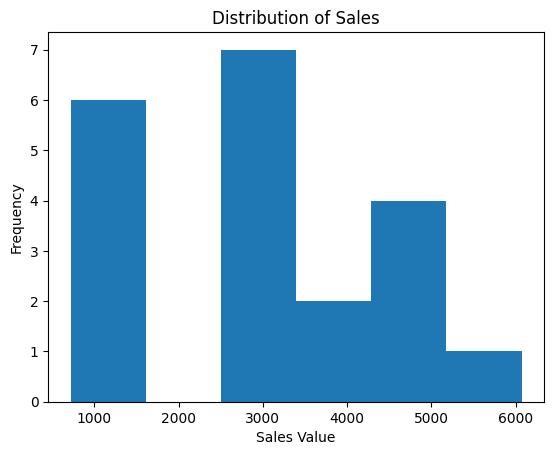

In [ ]:
plt.hist(df['Sales'],bins=6)
plt.xlabel('Sales Value')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

In [ ]:
q1 = df['Sales'].quantile(0.25)
q3 = df['Sales'].quantile(0.75)
iqr = q3-q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print(outliers)


Empty DataFrame
Columns: [Order_ID, Product_Category, Customer_Age, Quantity, Unit_Price, Discount, Delivery_Days, Sales]
Index: []


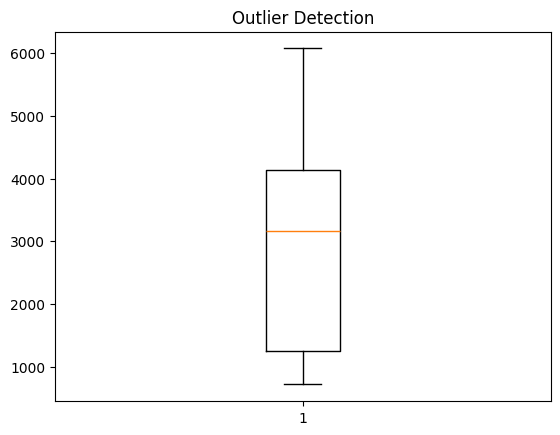

In [ ]:
plt.boxplot(df['Sales'])
plt.title('Outlier Detection')
plt.show()

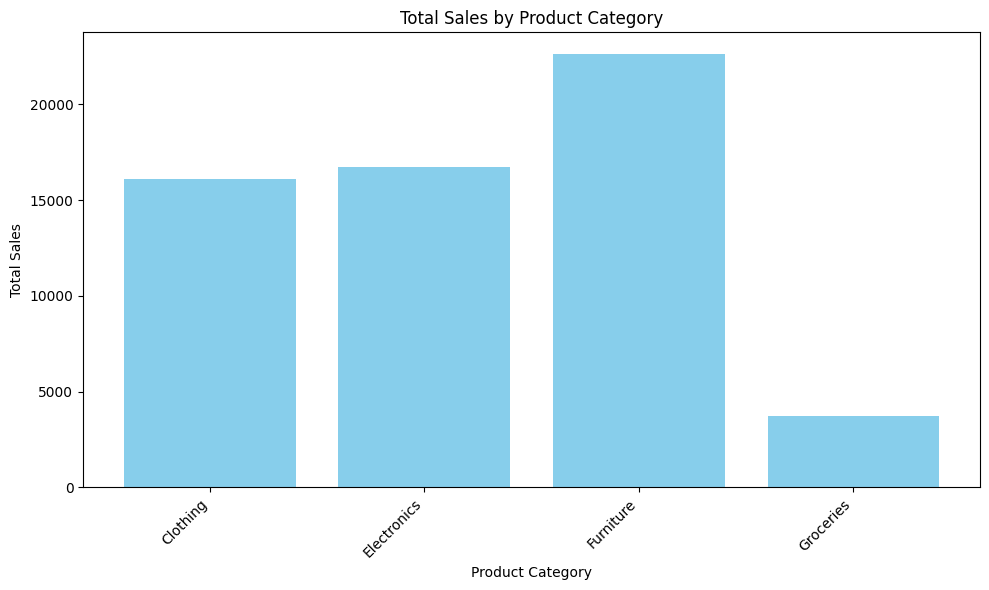

In [ ]:
sales_by_category = df.groupby('Product_Category')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(sales_by_category['Product_Category'], sales_by_category['Sales'])
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Furniture Category has High Sales

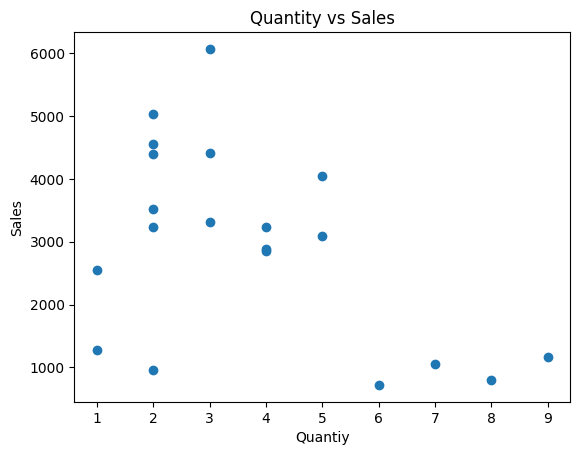

In [49]:
plt.scatter(df['Quantity'],df['Sales'])
plt.xlabel("Quantiy")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

As Quantity increases Sales Decreases/It Denotes that the Sales and Quantity have inverse relationship

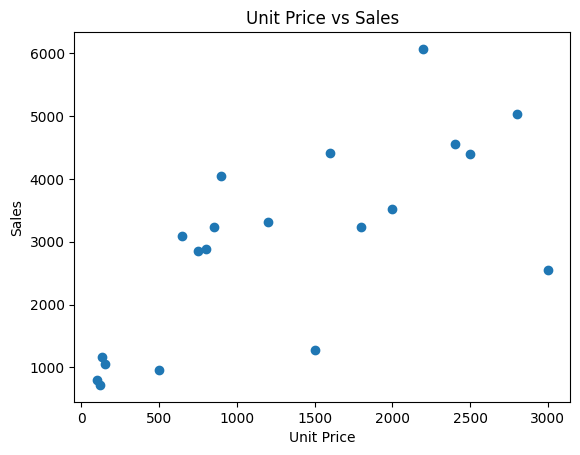

In [51]:
plt.scatter(df['Unit_Price'],df['Sales'])
plt.xlabel("Unit Price")
plt.ylabel("Sales")
plt.title("Unit Price vs Sales")
plt.show()

As Unit Price increases Sales Increases.It Denotes that the unit Price and Sales have Direct relationship

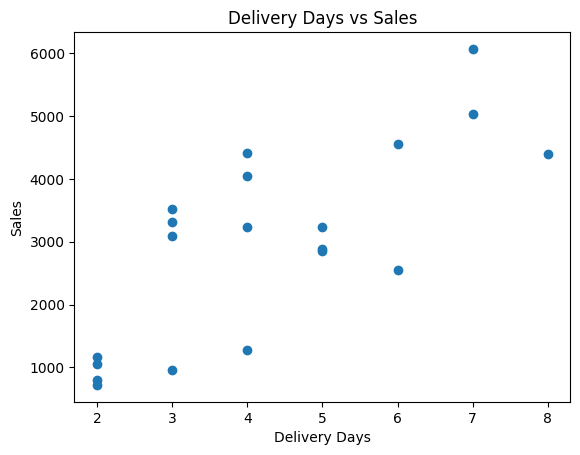

In [52]:
plt.scatter(df['Delivery_Days'],df['Sales'])
plt.xlabel("Delivery Days")
plt.ylabel("Sales")
plt.title("Delivery Days vs Sales")
plt.show()

There is no signicant relationship among these two variables.

# 5.Correlation

               Delivery_Days  Discount  Unit_Price  Quantity     Sales
Delivery_Days       1.000000  0.555531    0.801240 -0.623873  0.755337
Discount            0.555531  1.000000    0.552569 -0.497068  0.259886
Unit_Price          0.801240  0.552569    1.000000 -0.795071  0.710890
Quantity           -0.623873 -0.497068   -0.795071  1.000000 -0.488171
Sales               0.755337  0.259886    0.710890 -0.488171  1.000000


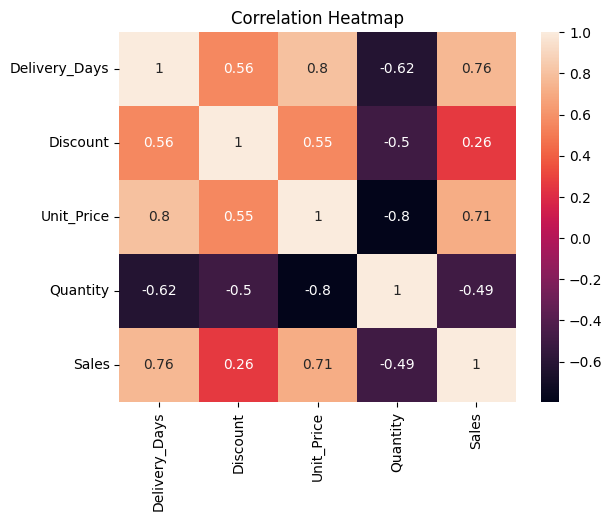

In [57]:
numeric_df = df[
    [
        "Delivery_Days",
        "Discount",
        "Unit_Price",
        "Quantity",
        "Sales"
    ]
]
corr = numeric_df.corr()
print(corr)
sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

Delivery Days and Unit Price have Strong Relationships towards Sales

Positive Relationships with Sales : Delivery Days,Unit price,Discount


Negative Relationship with Sales : Quantity

# Regression

In [60]:
X =df[[
    'Quantity',
    'Unit_Price',
    'Customer_Age',
    'Discount',
    'Delivery_Days']
]
y =df['Sales']
model = LinearRegression()


In [67]:
X

,Quantity,Unit_Price,Customer_Age,Discount,Delivery_Days
0,2,500,25,5,3
1,4,800,32,10,5
2,6,120,28,0,2
3,1,1500,41,15,4
4,3,2200,35,8,7
5,5,650,24,5,3
6,2,1800,29,10,4
7,8,100,45,0,2
8,2,2500,38,12,8
9,4,750,27,5,5


In [68]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size = 0.25)

In [69]:
model.fit(xtrain,ytrain)

LinearRegression()

In [70]:
ypred = model.predict(xtest)

In [71]:
print(ypred)
print(ytest)

[1507.46698897 1525.15166521 5387.28362381 5044.46259534 2296.77504456]
7      800
0      950
15    5040
11    2550
5     3087
Name: Sales, dtype: int64
